# 1. Data collection and preprocessing
This repository detailed the list of processing and analysis how to retrieve a continuous diurnal LST during peak summer months with high spatial resolution.

| Data                 | Data source     | Access / Download source                                               | Preprocessing | Reference                              |
|----------------------|-----------------|------------------------------------------------------------------------|---------------|----------------------------------------|
| Daytime and Nighttime – Coarse     | MODIS           | APPEEARS - https://appeears.earthdatacloud.nasa.gov/                   | OSGeo4W Shell | [Modis_preprocessing](preprocessing/modis.txt)     |
| 		       | Himawari SST    | WinSCP - https://winscp.net/eng/download.php                           | OSGeo4W Shell | [Himawari_preprocessing](preprocessing/himawari.txt)  |
| Daytime – Fine       | Landsat 8 and 9 | Google Earth Engine - GEE code (Ermida et al., 2020) https://github.com/sofiaermida/Landsat_SMW_LST                  | GEE | [Landsat_preprocessing](preprocessing/landsat.txt)   |
| Nighttime – Fine   | ECOSTRESS       | APPEEARS - https://appeears.earthdatacloud.nasa.gov/                   | ArcGIS - Spatial analyst | Mosaic and Raster calculator to convert Kelvin into Celcius |

# 2. Data description

In [3]:
import pandas as pd
# load the list of images
image_list = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\xlsx\list_of_images_csv.csv")

# Preview first 40 rows
display(image_list.head(40))

,spatial,temporal,use,date,view_time_UTC,view_time_AEDT,file_ID
0,Fine,Daytime,Reference,7/01/2023,7/01/2023 0:04,7/01/2023 11:04,LC80920862023007LGN00
1,Fine,Daytime,Validation,8/01/2021,8/01/2021 0:10,8/01/2021 11:10,LC80930862021008LGN00
2,Fine,Daytime,Validation,19/01/2022,19/01/2022 0:10,19/01/2022 11:10,LC90930862022019LGN01
3,Fine,Daytime,Validation,20/01/2022,20/01/2022 0:04,20/01/2022 11:04,LC80920872022020LGN00
4,Fine,Nighttime,Reference,25/12/2022,25/12/2022 12:50,25/12/2022 23:50,ECO_L2T_LSTE.002_LST_doy2022359124954_aid0001_55S
5,Fine,Nighttime,Reference,25/12/2022,25/12/2022 12:50,25/12/2022 23:50,ECO_L2T_LSTE.002_LST_doy2022359125046_aid0001_55S
6,Fine,Nighttime,Validation,12/12/2021,12/12/2021 11:22,12/12/2021 22:22,ECO_L2T_LSTE.002_LST_doy2021346112222_aid0001_55S
7,Fine,Nighttime,Validation,9/02/2023,9/02/2023 12:50,9/02/2023 23:50,ECO_L2T_LSTE.002_LST_doy2023040114723_aid0001_55S
8,Coarse,Daytime,Reference,7/01/2023,6/01/2023 22:48,7/01/2023 9:48,MOD11A1.061_LST_Day_1km_doy2023007000000_aid0001
9,Coarse,Daytime,Validation,8/01/2021,7/01/2021 23:54,8/01/2021 10:54,MOD11A1.061_LST_Day_1km_doy2021008000000_aid0001


# 2. Coarse images: Mosaicking, Reprojection, Resampling
The STARFM preprocessing steps are shown below

## 2.2 Daytime
The himawari image does not fully cover the Port Philip bay. Extrapolation using IDW was conducted. The original resolution was 2km. It was resampled to 1km to fit with the MODIS data. Then the SST in the study area is extracted using this file
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\ppb_square_b.7z

Extraction of the MODIS using a full rectangle with width and height values multiple by 1km (Unit of MODIS)
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\MODIS_fishnet_diss.7z

After alignment with the reference extract the output using
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\MODIS_extractByMask.7z

Resampling to 30 m (Reference fine = Landasat). 
Corresponding file to get the width and height (same extent as reference image), the following file was used
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\modis_30m_fish_diss_e.7z

## 2.3 Nightime
Resampling to 70 m (Reference fine = ECOSTRESS).
Corresponding file to get the width and height (same extent as reference image), the following file was used
...\shapefile\modis_70m_fishnet_20230209_diss.7z

The full preprocessing workflow is available at:
- [Daytime data processing](preprocessing/daytime_preprocessing.txt)
- [Nighttime data processing](preprocessing/nighttime_preprocessing.txt)

# 3. Spatiotemporal data fusion
## 3.1. STARFM
To run STARFM, the following repository was used (Mileva et al. 2018)
https://github.com/nmileva/starfm4py?tab=readme-ov-file

[STARFM parameters](preprocessing/starfm_parameters.txt) 

## 3.2. FSDAF
To run FSDAF, the following repository was used (Zhu et al., 2016)

The imput land cover classification is found in 
- For daytime: .../raw/fsdaf_classification/day_RF_classification_extract.tif
- For nighttime: .../raw/fsdaf_classification/night_RF_classification_extract.tif

The classification was run in Google Earth Engine (image on 14/01/2023)
https://code.earthengine.google.com/70404941027acb110eceaa87214e1f5e 

A winter classification was also conducted (image on 31/08/2022)
https://code.earthengine.google.com/2d39fb8fda1d8cc0efa7106107c28896 

# 4. Accuracy assessment
The following metrics were adopted from Zhu et al. (2022). Reference (observed) images were selected outside the analysis period (December 2022–February 2023) but within the same season in the nearest available years.
https://www.sciencedirect.com/science/article/pii/S003442572200116X?via%3Dihub#f0020 

Some reference images occasionally contain clouds. To address this, LST values were extracted only from cloud-free areas.

| Temporal   | Extraction      				      |
|------------|------------------------------------------------|
| Daytime    | …/shapefile/landsat_20220120_extract_fish.7z   |
| Nighttime  | …/shapefile/modis_70m_fishnet_20230209_diss.7z |

The nighttime reference raster contained no-data values, which were filled using the data-filling procedure described in [Data filling](preprocessing/reference_filling.txt).

## 4.1 Some scenes of observed and predicted LST

## 4.2 Accuracy assessment
(Zhu et al., 2022).   
https://www.sciencedirect.com/science/article/pii/S003442572200116X?via%3Dihub#f0020 
https://github.com/XZhu-lab/Fusion-accuracy-assessment

markdown_table = """
| Method | 1st input | 2nd input | Observations |
|--------|-----------|-----------|--------------|
| STARFM | Fine reference image | Fused image | - |
| FSDAF | Fine reference image | Fused image | - |
| F0 | Fine reference image | Fine base image  | - |
| CP | Fine reference image | Coarse reference image | - |
| ATF | Fine reference image | Fine base + (Fine reference − Fine base) × scaling factor | ∆T: temporal change from base time (t₀) to prediction time (tₚ) |
| ASF | Fine reference image | Coarse reference + (Fine reference − Coarse Reference) × scaling factor | ∆S: spatial difference between fine and coarse images (spatial sharpness term) |

Although the fusion framework allows user-defined amplification of temporal and spatial terms, no additional scaling was applied in this study (scaling factor = 1.5) to preserve the physical realism of land surface temperature and avoid over-amplification of thermal contrasts.

Run raster caluclator to get [∆T and ∆S](preprocessing/deltaT_deltaS_raster_calculator.txt)

For visualisation using the Taylor Diagram, the code by (Zhu et al., 2022) has been modified as the points are visibles only for 6 methods, not for 2. 
[APA Taylor Diagram](preprocessing/apa_taylor_diagram.txt)


| Daytime: 08/01/2021 | Daytime: 19/01/2022 | Daytime: 20/01/2022 |
|---------|---------|---------|
| <a href="jpg/APA_day_20210108.jpg" target="_blank"><img src="jpg/APA_day_20210108.jpg" width="450"/></a> | <a href="jpg/APA_day_20220119.jpg" target="_blank"><img src="jpg/APA_day_20220119.jpg" width="450"/></a> | <a href="jpg/APA_day_20220120.jpg" target="_blank"><img src="jpg/APA_day_20220120.jpg" width="450"/></a> |

| Nighttime: 12/12/2021 | Nighttime: 09/02/2023 |
|-----------|-----------|
| <a href="jpg/APA_night_20211212.jpg" target="_blank"><img src="jpg/APA_night_20211212.jpg" width="450"/></a> | <a href="jpg/APA_night_20230209.jpg" target="_blank"><img src="jpg/APA_night_20230209.jpg" width="450"/></a> |



# 4. DEASE
### Zonal Statistics of Predicted LST

Zonal statistics were applied to:
- **STARFM** outputs for **daytime LST prediction**
- **FSDAF** outputs for **night-time LST prediction**

For each prediction date, the **mean Land Surface Temperature (LST)** was extracted:
- by **date**, and  
- by **direction** (12 radial directions),

using zones defined from the **centre point of the image**.

<img src="jpg/accuracy_DEASE_bearing_centre_point.jpg" width="600"/>



In [3]:
import pandas as pd
import glob
import os

# Folder containing your CSV files
dease_csv_folder = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\DEASE_csv"

# Get all CSV files
csv_files = glob.glob(os.path.join(dease_csv_folder, "*.csv"))

# Read and concatenate
dease_all_df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

# Rename columns
dease_all_df = dease_all_df.rename(columns={
    "ID": "id",
    "MEAN": "mean_lst"
})

# Keep only relevant columns
dease_all_df = dease_all_df[["temporal", "use", "date", "id", "mean_lst"]]

# Load the Constructed DEASE CSV metadata
buffer_df = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\constructed_buffers_metadata.csv")

# Make sure 'id' is string for merging
dease_all_df["id"] = dease_all_df["id"].astype(str)
buffer_df["id"] = buffer_df["id"].astype(str)

print(dease_all_df["id"].dtype)
print(buffer_df["id"].dtype)

# Join with the metadata
dease_all_df_metadata = dease_all_df.merge(buffer_df, on="id", how="left")   

## Ensure the "Centre of urban areas" has rows for each bearing
# Filter DEASE for centre of urban areas --> distance == 0
dease_centre = dease_all_df_metadata[dease_all_df_metadata["distance"] == 0]

# DEASE centre, Bearing 255, 285, 315, 345, (15 is already in the dataset), 45, 75
dease_centre_255 = dease_centre.copy()
dease_centre_255["direction"] = 255

dease_centre_285 = dease_centre.copy()
dease_centre_285["direction"] = 285

dease_centre_315 = dease_centre.copy()
dease_centre_315["direction"] = 315

dease_centre_345 = dease_centre.copy()
dease_centre_345["direction"] = 345

dease_centre_45 = dease_centre.copy()
dease_centre_45["direction"] = 45

dease_centre_75 = dease_centre.copy()
dease_centre_75["direction"] = 75

dease_centre_105 = dease_centre.copy()
dease_centre_105["direction"] = 105

dease_centre_135 = dease_centre.copy()
dease_centre_135["direction"] = 135

dease_centre_165 = dease_centre.copy()
dease_centre_165["direction"] = 165

dease_centre_195 = dease_centre.copy()
dease_centre_195["direction"] = 195

dease_centre_225 = dease_centre.copy()
dease_centre_225["direction"] = 225

# Concatenate all centre rows
dease_centre_all = pd.concat([
    dease_centre_255,
    dease_centre_285,
    dease_centre_315,
    dease_centre_345,
    dease_centre_45,
    dease_centre_75
], ignore_index=True)

# Combine with the original DEASE dataset
dease_all_df_metadata = pd.concat([dease_all_df_metadata, dease_centre_all], ignore_index=True)

# Save merged CSV
out_csv = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\dease_all_dates.csv"
dease_all_df_metadata.to_csv(out_csv, index=False)

dease_all_df_metadata.head()

object
object


,temporal,use,date,id,mean_lst,distance,direction,area
0,day,prediction,3/12/2022,361,37.179070,0,15,0.900000
1,day,prediction,3/12/2022,1,39.077419,1,165,26.158868
2,day,prediction,3/12/2022,2,38.719252,2,165,78.532089
3,day,prediction,3/12/2022,3,38.779878,3,165,130.916650
4,day,prediction,3/12/2022,4,38.709621,4,165,183.310422


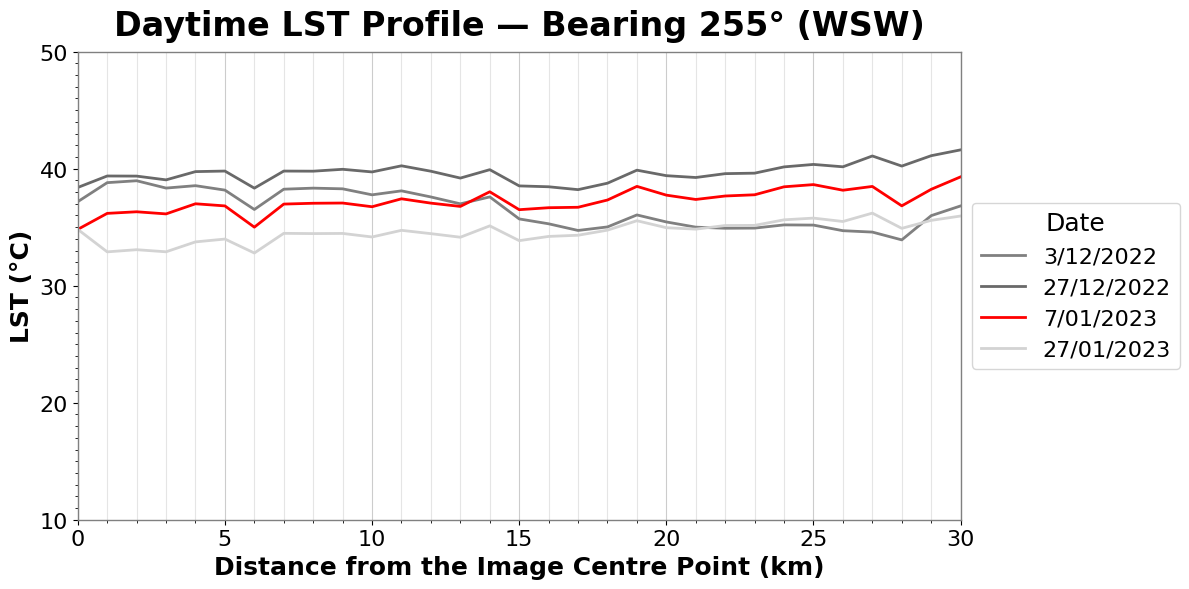

In [7]:
# Plot - One sample row from the DEASE dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Copy the dease csv file to a shorter name
dease_df = dease_all_df_metadata.copy()

# Filter for direction and temporal
dease_df_day_255 = dease_df[(dease_df["direction"] == 255) & (dease_df["temporal"] == "day")]

# Cubic smoothing spline per date
dease_df_day_255_raw = (
    dease_df_day_255[["date", "distance", "mean_lst"]]
    .sort_values(["date", "distance"])
    .reset_index(drop=True)
)

# Order dates (oldest --> newest)
date_order = [
    "3/12/2022",
    "27/12/2022",
    "7/01/2023",
    "27/01/2023"
]

dease_df_day_255_raw["date"] = pd.Categorical(
    dease_df_day_255_raw["date"],
    categories=date_order,
    ordered=True
)

# Define colours
date_colors = {
    "3/12/2022":  "gray",
    "27/12/2022": "dimgray",
    "7/01/2023":  "red",
    "27/01/2023": "lightgray"
}

# Plot smoothed curves
fig, ax = plt.subplots(figsize=(12, 6))

for date, g in dease_df_day_255_raw.groupby("date"):
    ax.plot(
        g["distance"],
        g["mean_lst"],
        label=date,
        color=date_colors.get(date, "gray"),
        linewidth=2
    )

# Axis labels and title
ax.set_xlim(0, 30)
ax.set_ylim(10, 50)

ax.set_xticks(np.arange(0, 31, 5))
ax.set_xticks(np.arange(0, 31, 1), minor=True)

ax.set_yticks(np.arange(10, 51, 10))
ax.set_yticks(np.arange(10, 51, 1), minor=True)


# labels and title
ax.set_title("Daytime LST Profile — Bearing 255° (WSW)", fontsize=24, fontweight="bold", pad=12)

ax.set_xlabel("Distance from the Image Centre Point (km)", fontsize=18, fontweight="bold")
ax.set_ylabel("LST (°C)", fontsize=18, fontweight="bold")

# Grid, legend, Styling 
ax.grid(which="major", axis="x", color="grey", alpha=0.4)
ax.grid(which="minor", axis="x", color="grey", alpha=0.2)

ax.tick_params(axis="both", labelsize=16)

legend = ax.legend(
    title="Date",
    fontsize=16,
    title_fontsize=18,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

for spine in ax.spines.values():
    spine.set_color("grey")
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()


#
In R, run the code [DEASE day](preprocessing/dease_example_day.txt). 
In R, run the code [DEASE night](preprocessing/dease_example_night.txt). 

Previous versions were
[DEASE day spline and GAM](preprocessing/dease_example_day_spline_gam.txt) and [DEASE night spline and GAM](preprocessing/dease_example_night_spline_gam.txt)

<table align="center">
  <tr>
    <th style="text-align:center;">Daytime</th>
    <th style="text-align:center;">Nighttime</th>
  </tr>
  <tr>
    <td><img src="png/day_direction_15.png" width="600"/></td>
    <td><img src="png/night_direction_15.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_45.png" width="600"/></td>
    <td><img src="png/night_direction_45.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_75.png" width="600"/></td>
    <td><img src="png/night_direction_75.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_105.png" width="600"/></td>
    <td><img src="png/night_direction_105.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_135.png" width="600"/></td>
    <td><img src="png/night_direction_135.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_165.png" width="600"/></td>
    <td><img src="png/night_direction_165.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_195.png" width="600"/></td>
    <td><img src="png/night_direction_195.png" width="600"/></td>
  </tr>
    <td><img src="png/day_direction_225.png" width="600"/></td>
    <td><img src="png/night_direction_225.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_255.png" width="600"/></td>
    <td><img src="png/night_direction_255.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_285.png" width="600"/></td>
    <td><img src="png/night_direction_285.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_315.png" width="600"/></td>
    <td><img src="png/night_direction_315.png" width="600"/></td>
  </tr>
  <tr>
    <td><img src="png/day_direction_345.png" width="600"/></td>
    <td><img src="png/night_direction_345.png" width="600"/></td>
  </tr>
</table>



Extract LST profiles along each bearing for reference and prediction dates

Smooth each profile using a cubic spline GAM

Compute first-order spatial derivatives along distance

Compare derivatives between prediction and reference profiles

Summarise agreement using gradient-based accuracy metrics

In [10]:
# GAM by date - direction
# Daytime - Bearing 45° (NE)
# Filter for direction and temporal
dease_df_day_45 = dease_df[(dease_df["direction"] == 45) & (dease_df["temporal"] == "day")]

# Cubic smoothing spline per date
dease_dfs = []

for date, g in dease_df_day_45.groupby("date"):
    g = g.sort_values("distance")

    X = g["distance"].values.reshape(-1, 1)
    y = g["mean_lst"].values

    # Cubic smoothing spline
    gam = LinearGAM(s(0, spline_order=3)).fit(X, y)
    y_pred = gam.predict(X)

    # Replace spline value at distance == 0 with observed value
    idx0 = np.where(g["distance"].values == 0)[0]
    if len(idx0) == 1:
        y_pred[idx0[0]] = y[idx0[0]]

    dease_dfs.append(pd.DataFrame({
        "distance": g["distance"].values,
        "mean_lst": y_pred,
        "date": date,
        "direction": g["direction"].values
    }))

dease_df_day_45_spline = pd.concat(dease_dfs, ignore_index=True)

dease_df_day_45_spline.head()

,distance,mean_lst,date,direction
0,0,31.059919,27/01/2023,45
1,5,31.564382,27/01/2023,45
2,6,31.625389,27/01/2023,45
3,7,31.683914,27/01/2023,45
4,8,31.736160,27/01/2023,45


# 4. Comparison against air temperature at BOM stations
The LST data for the target dates were compared with air temperature.


### 3.1.1 LST extraction
First, the fused STARFM outputs were exported to the output folder using filenames such as `d_refer_20230107`, in which the date is encoded as an 8-character string (`YYYYMMDD`) and preceded by an additional 8 characters.

Secondly, for each raster file in the output folder, the LST is extracted using the PWRS and CWS shapefile 
...\shapefile\wn_bom_pt.7z
To do the extraction, the following code was used in ARCGIS [PRWS and CWS LST](preprocessing/pwrs_cws_lst_extraction.txt)

### 3.1.2 LST vs Air temperature

In [2]:
# load the extracted LST data
day_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_pwrs_cws_lst.csv")
night_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_pwrs_cws_lst.csv")

# LST Convert the date column to datetime format
day_lst['date'] = pd.to_datetime(day_lst['date'], format='%d/%m/%Y')
night_lst['date'] = pd.to_datetime(night_lst['date'], format='%d/%m/%Y')

# Add the Time_AEDT column
day_lst['Time_AEDT'] = pd.to_datetime(day_lst['date']) + pd.Timedelta(hours=11)
night_lst['Time_AEDT'] = pd.to_datetime(night_lst['date']) + pd.Timedelta(hours=24)

# Add temporal information to day_lst and night_lst
day_lst['temporal'] = 'day'
night_lst['temporal'] = 'night'

# Keep the date format only day/month/year
day_lst['date'] = day_lst['date'].dt.strftime('%d/%m/%Y')
night_lst['date'] = night_lst['date'].dt.strftime('%d/%m/%Y')

# Add use information whether reference or target
day_lst['use'] = day_lst['date'].eq('07/01/2023').map({True: 'reference', False: 'target'})
night_lst['use'] = night_lst['date'].eq('25/12/2022').map({True: 'reference', False: 'target'})

# Merge day_lst with night_lst
day_night_lst = pd.concat([day_lst, night_lst], ignore_index=True)

# Preview first 40 rows
display(day_night_lst.head(5))

NameError: name 'pd' is not defined

In [9]:
# load the air temperature data with UHI inn Chapter 1
air_temp = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\chapter1\output\pwrs_cws_raw.csv")

# Keep only relevant columns
air_temp = air_temp[['p_id', 'Time_AEDT', 'Time_UTC', 'ta']]

# Preview first 5 rows
display(air_temp.head(5))

c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\IPython\core\interactiveshell.py:3553: DtypeWarning: Columns (2) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,p_id,Time_AEDT,Time_UTC,ta
0,200,2022-12-01 00:00:00,2022-11-30 13:00:00,13.9
1,200,2022-12-01 01:00:00,2022-11-30 14:00:00,12.7
2,200,2022-12-01 02:00:00,2022-11-30 15:00:00,12.1
3,200,2022-12-01 03:00:00,2022-11-30 16:00:00,11.9
4,200,2022-12-01 04:00:00,2022-11-30 17:00:00,12.5


In [11]:
# Make sure both Time_AEDT columns are datetime
air_temp['Time_AEDT'] = pd.to_datetime(air_temp['Time_AEDT'])
day_night_lst['Time_AEDT'] = pd.to_datetime(day_night_lst['Time_AEDT'])

# Merge LST with air temperature data
lst_air_temp = pd.merge(day_night_lst, air_temp, on=['p_id', 'Time_AEDT'], how='inner')

# Keep the date format only day/month/year
# lst_air_temp['date'] = lst_air_temp['date'].dt.strftime('%d/%m/%Y')

# Order columns
lst_air_temp = lst_air_temp[['temporal', 'use', 'p_id', 'source', 'date', 'Time_AEDT', 'Time_UTC', 'lst_pred', 'ta']]

# Preview first 5 rows
display(lst_air_temp.head(5))

,temporal,use,p_id,source,date,Time_AEDT,Time_UTC,lst_pred,ta
0,day,target,1004,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,33.198058,25.4
1,day,target,1010,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.639220,26.6
2,day,target,1011,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.363447,25.7
3,day,target,1016,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.205113,22.7
4,day,target,1017,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.664265,25.3


In [12]:
# Filter PRWS only
lst_air_temp_prws = lst_air_temp[lst_air_temp['source'] == 'prws']

# Check the number of rows
num_rows = len(lst_air_temp_prws)
print(f"Number of rows for PRWS only: {num_rows}.")

# Preview all rows
display(lst_air_temp_prws.head(num_rows))

# Export to CSV
lst_air_temp_prws.to_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\lst_air_temp_prws.csv", index=False)

Number of rows for PRWS only: 45.


,temporal,use,p_id,source,date,Time_AEDT,Time_UTC,lst_pred,ta
241,day,target,400,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,33.751797,26.1
242,day,target,200,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,37.289041,26.7
243,day,target,600,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,37.697760,28.3
244,day,target,500,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,38.241858,27.3
245,day,target,300,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,35.678723,26.6
503,day,target,400,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,36.009568,31.6
504,day,target,200,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,39.431096,32.6
505,day,target,600,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,41.721304,33.4
506,day,target,500,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,38.050427,31.5
507,day,target,300,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,38.510894,32.6


### 3.1.3 Plot
To compare the LST with the Air temperature, the equivalent R code can be found [here](preprocessing/R_lst_air_temperature_plot.txt)

Paired t-test: Ttest_relResult(statistic=-16.11430228750514, pvalue=1.5505126851563265e-12)
Paired Wilcoxon test: WilcoxonResult(statistic=0.0, pvalue=1.9073486328125e-06)


c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\ipykernel_launcher.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


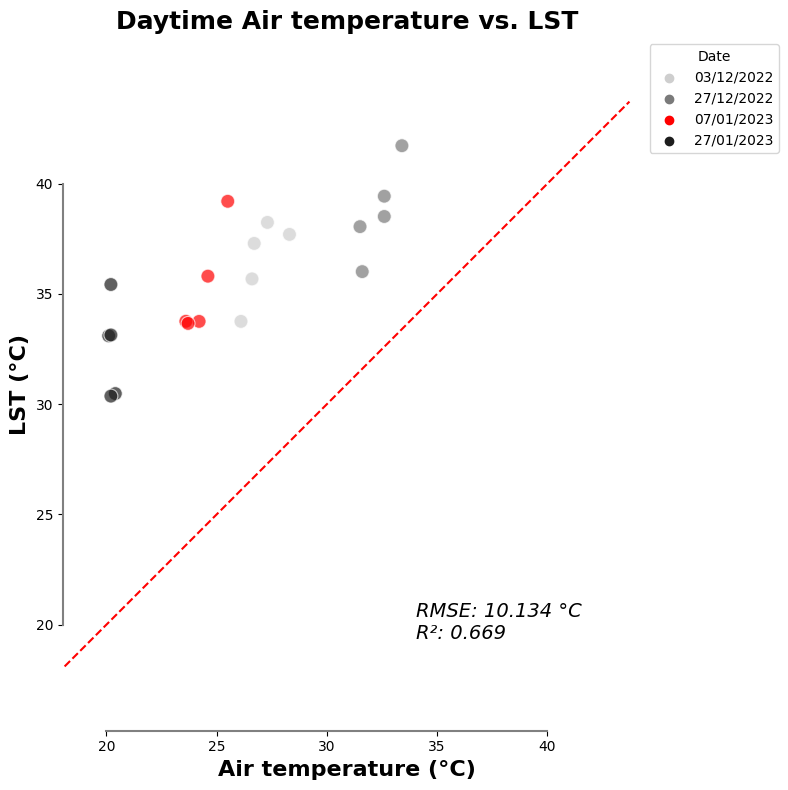

Paired t-test (night): Ttest_relResult(statistic=1.7998253164917721, pvalue=0.08447318334915456)
Paired Wilcoxon test (night): WilcoxonResult(statistic=104.0, pvalue=0.11993378400802612)
Paired t-test (night): Ttest_relResult(statistic=1.7998253164917721, pvalue=0.08447318334915456)
Paired Wilcoxon test (night): WilcoxonResult(statistic=104.0, pvalue=0.11993378400802612)


c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\ipykernel_launcher.py:270: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


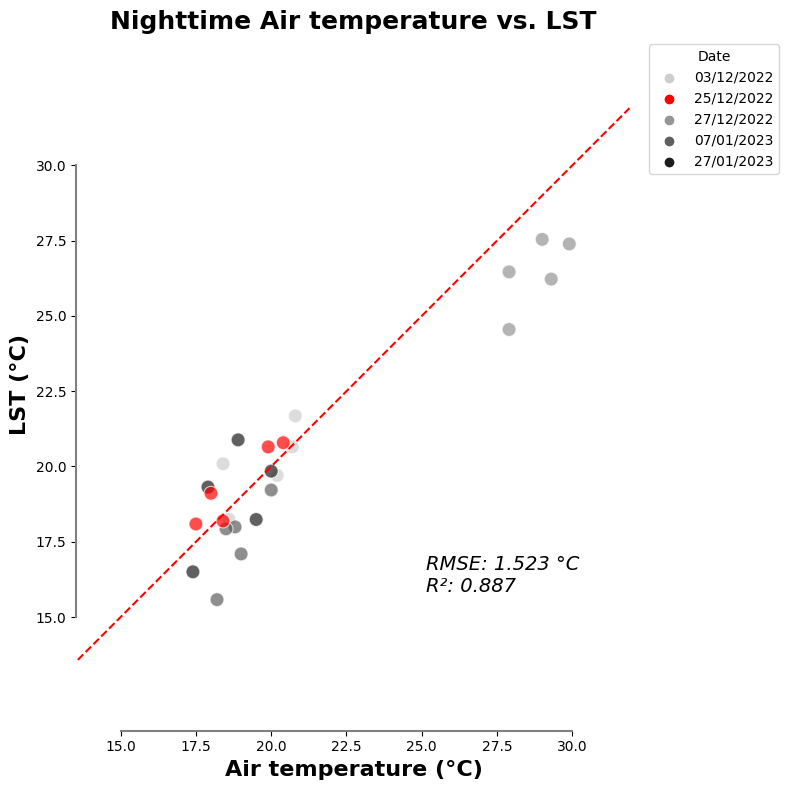

In [43]:
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib.colors import to_hex
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Filter temporal == 'day'
# -------------------------
lst_air_temp_prws_day = lst_air_temp_prws[lst_air_temp_prws['temporal'] == 'day'].copy()

# -------------------------
# Paired tests
# -------------------------
t_test_result_day = stats.ttest_rel(
    lst_air_temp_prws_day['ta'],
    lst_air_temp_prws_day['lst_pred'],
    nan_policy='omit'
)
print("Paired t-test:", t_test_result_day)

wilcox_result_day = stats.wilcoxon(
    lst_air_temp_prws_day['ta'],
    lst_air_temp_prws_day['lst_pred'],
    zero_method='wilcox',
    alternative='two-sided'
)
print("Paired Wilcoxon test:", wilcox_result_day)

# -------------------------
# R² and RMSE
# -------------------------
r2 = np.corrcoef(
    lst_air_temp_prws_day['ta'],
    lst_air_temp_prws_day['lst_pred']
)[0, 1] ** 2

rmse = np.sqrt(
    np.mean((lst_air_temp_prws_day['ta'] - lst_air_temp_prws_day['lst_pred']) ** 2)
)

info_text = f"RMSE: {rmse:.3f} °C\nR²: {r2:.3f}"

# -------------------------
# Set plot limits
# -------------------------
min_val = min(
    lst_air_temp_prws_day['ta'].min(),
    lst_air_temp_prws_day['lst_pred'].min()
)
max_val = max(
    lst_air_temp_prws_day['ta'].max(),
    lst_air_temp_prws_day['lst_pred'].max()
)

# -------------------------
# Date handling
# -------------------------
lst_air_temp_prws['date'] = pd.to_datetime(
    lst_air_temp_prws['date'],
    dayfirst=True
)

lst_air_temp_prws_day['date'] = pd.to_datetime(
    lst_air_temp_prws_day['date'],
    dayfirst=True
)

# -------------------------
# Create date_str (used for hue & palette)
# -------------------------
lst_air_temp_prws_day['date_str'] = lst_air_temp_prws_day['date'].dt.strftime('%d/%m/%Y')

# -------------------------
# Target dates (string-based, ordered)
# -------------------------
target_dates_str = (
    lst_air_temp_prws_day.loc[
        lst_air_temp_prws_day['use'] == 'target', 'date_str'
    ]
    .drop_duplicates()
    .sort_values(
        key=lambda x: pd.to_datetime(x, dayfirst=True)
    )
)

# -------------------------
# Grey → black gradient
# -------------------------
cmap = plt.cm.Greys
gradient_colors = [
    to_hex(cmap(i))
    for i in np.linspace(0.3, 0.9, len(target_dates_str))
]

target_color_map = dict(zip(target_dates_str, gradient_colors))

# -------------------------
# Full palette
# -------------------------
palette = {}

for _, row in lst_air_temp_prws_day[['date_str', 'use']].drop_duplicates().iterrows():
    if row['use'] == 'target':
        palette[row['date_str']] = target_color_map[row['date_str']]
    else:
        palette[row['date_str']] = 'red'


# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=lst_air_temp_prws_day,
    x='ta',
    y='lst_pred',
    hue='date_str',
    palette=palette,
    s=100,
    alpha=0.7
)

# Identity line
plt.plot(
    [min_val - 2, max_val + 2],
    [min_val - 2, max_val + 2],
    ls='--',
    color='red'
)

# Annotation
plt.text(
    x=18 + 0.6 * (max_val - 15),
    y=18 + 0.05 * (max_val - 15),
    s=info_text,
    fontsize=14,
    fontstyle='italic',
    color='black'
)

# Labels
plt.title("Daytime Air temperature vs. LST", fontsize=18, fontweight='bold')
plt.xlabel("Air temperature (°C)", fontsize=16, fontweight='bold')
plt.ylabel("LST (°C)", fontsize=16, fontweight='bold')

# Axis limits
plt.xlim(min_val -2, max_val + 2)
plt.ylim(min_val -2, max_val + 2)

# Square axes
plt.gca().set_aspect('equal', adjustable='datalim')

# Frame styling
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('grey')

ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

sns.despine(trim=True)
plt.grid(False)

# -------------------------
# Chronological legend
# -------------------------
# Get handles and labels
handles, labels = ax.get_legend_handles_labels()

# Convert labels back to datetime
labels_dates = pd.to_datetime(labels, dayfirst=True)

# Get the order
order = np.argsort(labels_dates)

# Reorder legend
plt.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    title='Date',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)


# -------------------------
# Save figure
# -------------------------
plt.tight_layout()
plt.savefig(
    "20260201_bom_day_observed_vs_predicted.png",
    dpi=300
)
plt.show()

#--------------------------------------------------------------------------------------------------------
# -------------------------
# Filter temporal == 'night'
# -------------------------
lst_air_temp_prws_night = lst_air_temp_prws[lst_air_temp_prws['temporal'] == 'night'].copy()

# -------------------------
# Paired tests
# -------------------------
t_test_result_night = stats.ttest_rel(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    nan_policy='omit'
)
print("Paired t-test (night):", t_test_result_night)

wilcox_result_night = stats.wilcoxon(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    zero_method='wilcox',
    alternative='two-sided'
)
print("Paired Wilcoxon test (night):", wilcox_result_night)

t_test_result_night = stats.ttest_rel(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    nan_policy='omit'
)
print("Paired t-test (night):", t_test_result_night)

wilcox_result_night = stats.wilcoxon(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    zero_method='wilcox',
    alternative='two-sided'
)
print("Paired Wilcoxon test (night):", wilcox_result_night)
# -------------------------
# R² and RMSE
# -------------------------
r2 = np.corrcoef(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred']
)[0, 1] ** 2

rmse = np.sqrt(
    np.mean((lst_air_temp_prws_night['ta'] - lst_air_temp_prws_night['lst_pred']) ** 2)
)

info_text = f"RMSE: {rmse:.3f} °C\nR²: {r2:.3f}"

# -------------------------
# Set plot limits
# -------------------------
min_val = min(
    lst_air_temp_prws_night['ta'].min(),
    lst_air_temp_prws_night['lst_pred'].min()
)
max_val = max(
    lst_air_temp_prws_night['ta'].max(),
    lst_air_temp_prws_night['lst_pred'].max()
)

# -------------------------
# Date handling
# -------------------------
lst_air_temp_prws['date'] = pd.to_datetime(
    lst_air_temp_prws['date'],
    dayfirst=True
)

lst_air_temp_prws_night['date'] = pd.to_datetime(
    lst_air_temp_prws_night['date'],
    dayfirst=True
)

# -------------------------
# Create date_str (used for hue & palette)
# -------------------------
lst_air_temp_prws_night['date_str'] = lst_air_temp_prws_night['date'].dt.strftime('%d/%m/%Y')

# -------------------------
# Target dates (string-based, ordered)
# -------------------------
target_dates_str = (
    lst_air_temp_prws_night.loc[
        lst_air_temp_prws_night['use'] == 'target', 'date_str'
    ]
    .drop_duplicates()
    .sort_values(
        key=lambda x: pd.to_datetime(x, dayfirst=True)
    )
)

# -------------------------
# Grey → black gradient
# -------------------------
cmap = plt.cm.Greys
gradient_colors = [
    to_hex(cmap(i))
    for i in np.linspace(0.3, 0.9, len(target_dates_str))
]

target_color_map = dict(zip(target_dates_str, gradient_colors))

# -------------------------
# Full palette
# -------------------------
palette = {}

for _, row in lst_air_temp_prws_night[['date_str', 'use']].drop_duplicates().iterrows():
    if row['use'] == 'target':
        palette[row['date_str']] = target_color_map[row['date_str']]
    else:
        palette[row['date_str']] = 'red'


# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=lst_air_temp_prws_night,
    x='ta',
    y='lst_pred',
    hue='date_str',
    palette=palette,
    s=100,
    alpha=0.7
)

# Identity line
plt.plot(
    [min_val -2, max_val + 2],
    [min_val -2, max_val + 2],
    ls='--',
    color='red'
)

# Annotation
plt.text(
    x=15 + 0.6 * (max_val - 13),
    y=15 + 0.05 * (max_val - 13),
    s=info_text,
    fontsize=14,
    fontstyle='italic',
    color='black'
)

# Labels
plt.title("Nighttime Air temperature vs. LST", fontsize=18, fontweight='bold')
plt.xlabel("Air temperature (°C)", fontsize=16, fontweight='bold')
plt.ylabel("LST (°C)", fontsize=16, fontweight='bold')

# Axis limits
plt.xlim(min_val - 2, max_val + 2)
plt.ylim(min_val - 2, max_val + 2)

# Square axes
plt.gca().set_aspect('equal', adjustable='datalim')

# Frame styling
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('grey')

ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

sns.despine(trim=True)
plt.grid(False)

# -------------------------
# Chronological legend
# -------------------------
# Get handles and labels
handles, labels = ax.get_legend_handles_labels()

# Convert labels back to datetime
labels_dates = pd.to_datetime(labels, dayfirst=True)

# Get the order
order = np.argsort(labels_dates)

# Reorder legend
plt.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    title='Date',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)


# -------------------------
# Save figure
# -------------------------
plt.tight_layout()
plt.savefig(
    "20260201_bom_night_observed_vs_predicted.png",
    dpi=300
)
plt.show()


## 3.3. Assessment of temporal stability of the model

## 3.4. Assessment of cross-date spatial pattern consistency

### a. Hotspot analysis

### b. Directional ring profiling using the urban-rural LST gradients

# References
- Ermida, S. L., Soares, P., Mantas, V., Göttsche, F.-M., & Trigo, I. F. (2020). Google earth engine open-source code for land surface temperature estimation from the landsat series. Remote Sensing, 12(9), 1471. 
- Gao, F., Masek, J., Schwaller, M., & Hall, F. (2006). On the blending of the Landsat and MODIS surface reflectance: Predicting daily Landsat surface reflectance. IEEE Transactions on Geoscience and Remote sensing, 44(8), 2207-2218.
- Mileva, N., Mecklenburg, S., & Gascon, F. (2018). New tool for spatio-temporal image fusion in remote sensing: A case study approach using Sentinel-2 and Sentinel-3 data. Image and Signal Processing for Remote Sensing Xxiv
- Zhu, X., Helmer, E. H., Gao, F., Liu, D., Chen, J., & Lefsky, M. A. (2016). A flexible spatiotemporal method for fusing satellite images with different resolutions. Remote Sensing of Environment, 172, 165-177. https://doi.org/https://doi.org/10.1016/j.rse.2015.11.016 
- Zhu, X., Zhan, W., Zhou, J., Chen, X., Liang, Z., Xu. S., Chen, J.2022. A novel framework to assess all-round performances of spatiotemporal fusion models, Remote Sensing of Environment，274，113002，https://doi.org/10.1016/j.rse.2022.113002 
